# Customer Segmentation Using K-Means

### Load dataset 

In [2]:
import pandas as pd

df = pd.read_csv("data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Dataset investigation 

In [3]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


### Missing values check

In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df.describe()

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Cleaning Result

After performing previouse manipulations on the dataset we can see that it is clean enough

In [6]:
df.head(20).to_csv("examples/cleaned_dataset_sample.csv", index=False)

### Praparing the data for K-Means

In [7]:
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### Scaling the features 

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

### Using Elbow Method to decide the num of clusters

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

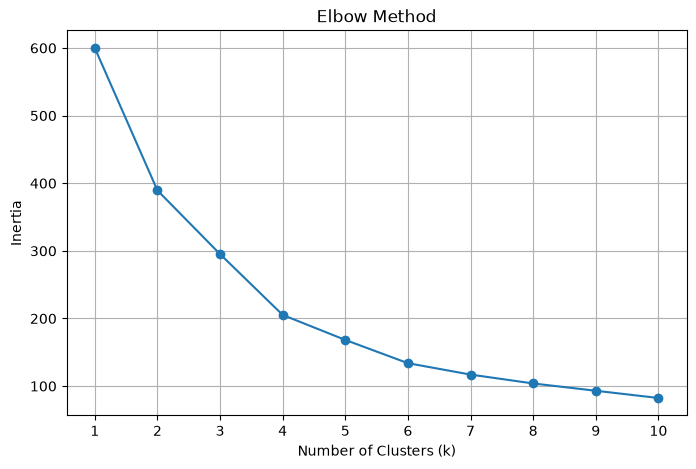

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 11))
plt.grid(True)
plt.savefig("images/elbow_method.png", bbox_inches="tight")
plt.show()

### Using second method Silhouette Score to decide the num of clusters

In [11]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"k = {k}: {score:.3f}")

k = 2: 0.335
k = 3: 0.358
k = 4: 0.404
k = 5: 0.417
k = 6: 0.428
k = 7: 0.417
k = 8: 0.408
k = 9: 0.418
k = 10: 0.407


### Based on two methods performed choosing k

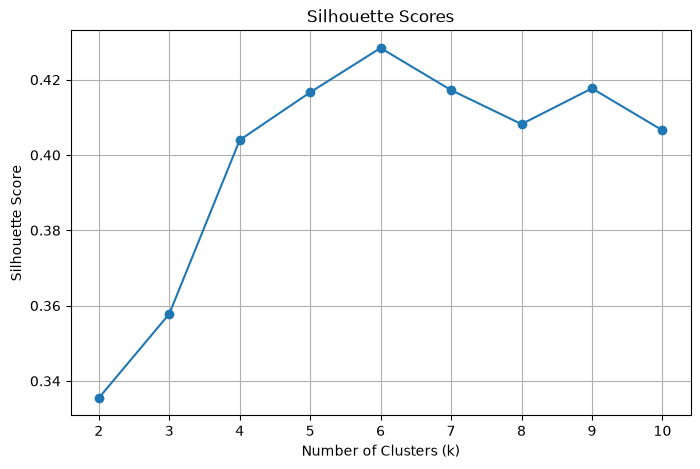

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.xticks(range(2, 11))
plt.grid(True)
plt.savefig("images/silhouette_scores.png", bbox_inches="tight")
plt.show()

### Training the K-Means Model 

In [13]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5


### Analysing the Customer Cluster

In [14]:
cluster_sizes = df["Cluster"].value_counts().sort_index()

print("Cluster sizes:")
print(cluster_sizes)

Cluster sizes:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64
